# Week 8 · Day 2 — Class
# Train, Predict, Evaluate — Properly 🚢

Yesterday you built your first model. Today we go one level deeper on the **most important question in ML:**

> *"How do I know if my model is actually any good?"*

We'll use a dataset you already know from Week 5 — the **Titanic** — so all your brain power goes to the ML, not the data.

**Today:**
1. Prep a real (messy) dataset for a model.
2. Train and predict survival.
3. Read accuracy **honestly**.
4. See a **confusion matrix** as a picture.
5. Compare **two models** and pick a winner.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. A model needs clean, numeric data

Real data is messy. Models can't handle missing values or text labels directly. You already learned to clean in Week 6 — we'll use those skills now.

We'll keep a few simple, useful columns:
- `pclass` (ticket class), `sex`, `age`, `fare`
- target = `survived` (0 = no, 1 = yes)

In [9]:
# Work on a copy (good habit — avoids chained-assignment bugs)
df = titanic[["pclass", "sex", "age", "fare", "survived"]].copy()

# How much is missing?
df.isnull().sum()

pclass        0
sex           0
age         177
fare          0
survived      0
dtype: int64

In [10]:
df['sex']

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: sex, Length: 891, dtype: object

In [11]:
# Fill missing ages with the median age (a Week 6 skill)
df["age"] = df["age"].fillna(df["age"].median())

# Models need numbers, not text. Turn 'sex' into 0/1.
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# Confirm: no missing values, all numeric
print(df.isnull().sum())
df.head()

pclass      0
sex         0
age         0
fare        0
survived    0
dtype: int64


,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


## 2. The 5-step recipe (same as yesterday)

In [12]:
# Step 1 — features and target
X = df[["pclass", "sex", "age", "fare"]]
y = df["survived"]

# Step 2 — train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3 — train a KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 4 — predict
knn_preds = knn.predict(X_test)

# Step 5 — score
print(f"KNN accuracy: {accuracy_score(y_test, knn_preds)*100:.1f}%")

KNN accuracy: 69.3%


## 3. Accuracy isn't the whole story

Say a model is 80% accurate. Good? Maybe. But **which** mistakes does it make? Does it wrongly say people died who actually survived, or the reverse?

A **confusion matrix** breaks the answers into four boxes:

|  | Predicted: Died | Predicted: Survived |
|--|--|--|
| **Actually Died** | ✅ correct | ❌ wrong |
| **Actually Survived** | ❌ wrong | ✅ correct |

The diagonal = correct. Off-diagonal = mistakes. Let's see it as a heatmap.

In [13]:
cm = confusion_matrix(y_test, knn_preds)
cm

array([[88, 17],
       [38, 36]])

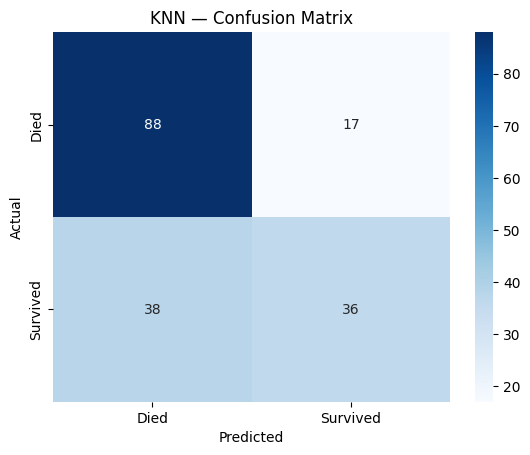

In [14]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died", "Survived"],
            yticklabels=["Died", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN — Confusion Matrix")
plt.show()

**How to read it:** big numbers on the diagonal (top-left, bottom-right) are good — those are correct predictions. The other two boxes are the mistakes. Now you can *see* whether the model favors one answer.

## 4. Compare two models

Which is better for this problem — **KNN** or **Logistic Regression**? Same data, same split. Let the accuracy decide.

In [15]:
# Train a Logistic Regression on the exact same split
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

knn_acc = accuracy_score(y_test, knn_preds)
logreg_acc = accuracy_score(y_test, logreg_preds)

print(f"KNN accuracy:                {knn_acc*100:.1f}%")
print(f"Logistic Regression accuracy: {logreg_acc*100:.1f}%")

winner = "KNN" if knn_acc > logreg_acc else "Logistic Regression"
print("Winner on this test set:", winner)

KNN accuracy:                69.3%
Logistic Regression accuracy: 80.4%
Winner on this test set: Logistic Regression


In [16]:
cm2 = confusion_matrix(y_test, logreg_preds)

In [17]:
cm2

array([[90, 15],
       [20, 54]])

## 5. Predict for a made-up passenger

Would a 1st-class, female, age-25 passenger paying fare 80 survive, according to our model?

In [18]:
# [pclass, sex(0=male,1=female), age, fare]
passenger = pd.DataFrame([[1, 1, 25, 80]],
                         columns=["pclass", "sex", "age", "fare"])
print(passenger)
result = logreg.predict(passenger)[0]
print("Prediction:", "Survived ✅" if result == 1 else "Did not survive ❌")

   pclass  sex  age  fare
0       1    1   25    80
Prediction: Survived ✅


In [19]:
# [pclass, sex(0=male,1=female), age, fare]
passenger = pd.DataFrame([[3, 0, 35, 20]],
                         columns=["pclass", "sex", "age", "fare"])
print(passenger)
result = logreg.predict(passenger)[0]
print("Prediction:", "Survived ✅" if result == 1 else "Did not survive ❌")

   pclass  sex  age  fare
0       3    0   35    20
Prediction: Did not survive ❌


In [23]:
# [pclass, sex(0=male,1=female), age, fare]
passenger = pd.DataFrame([[1, 1, 70, 80]],
                         columns=["pclass", "sex", "age", "fare"])
print(passenger)
result = logreg.predict(passenger)[0]
print("Prediction:", "Survived ✅" if result == 1 else "Did not survive ❌")

   pclass  sex  age  fare
0       1    1   70    80
Prediction: Survived ✅


## 🎯 What you learned today

- Real data needs **cleaning** before a model can use it (fill missing, text → numbers).
- **Accuracy** tells you *how often*; the **confusion matrix** tells you *which mistakes*.
- You can **compare models** on the same split and pick the better one.

Tomorrow is the big one — your **capstone project** that ties all 8 weeks together. Come ready! 🏆